# CSCI 345: Machine Learning
## Topic: Classification Models

**Name:** Josiah Howard  
**Date:** 9/2/2026  
**Estimated time:** 75–90 minutes

This notebook introduces two fundamental classification algorithms:
- Logistic Regression and K-Nearest Neighbors (KNN).

We will explore how these models can be used to classify observations,
prepare data for classification, make predictions, and evaluate model performance.


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Logistic Regression


Not all problems are continuous


- There are instances where we want to determine a binary state


- Logistic regression is good for qualitative results


- Logistic regression is concerned with the probability that a response falls into a particular category


## Evaluating Classification

- True Positives
- True Negatives
- False Positives
- False Negatives


Logistic regression uses a Sigmoid function for situations where outputs can have one of two values either 0 or 1


$$\omega(z)=\frac{1}{1+e^{-z}}$$


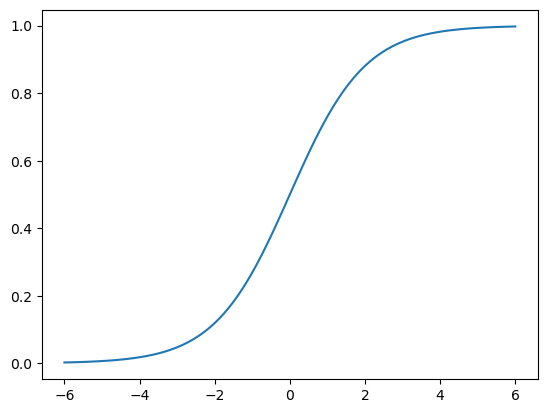

In [2]:
def sigmoid(x):
    return (1/(1+np.exp(-x)))

x = np.linspace(-6,6,100)
plt.plot(x,sigmoid(x))

**Take our linear regression solution and put it into a logistic model**

$$\omega(z)=\frac{1}{1+e^{-(x\beta + \epsilon)}}$$


## Example: Sinking of the Titanic

The Challenge:

The sinking of the Titanic is one of the most infamous shipwrecks in history.


On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.


While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.


In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).


In [3]:
# Use pandas to read in csv file
train = pd.read_csv('titanic.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Locates and Visualizes the Missing Values

- You cannot train a machine learning model with missing values. It will not know what to do.


In [5]:
# Use the .isnull() method to locate missing data
missing_values = train.isnull()
missing_values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

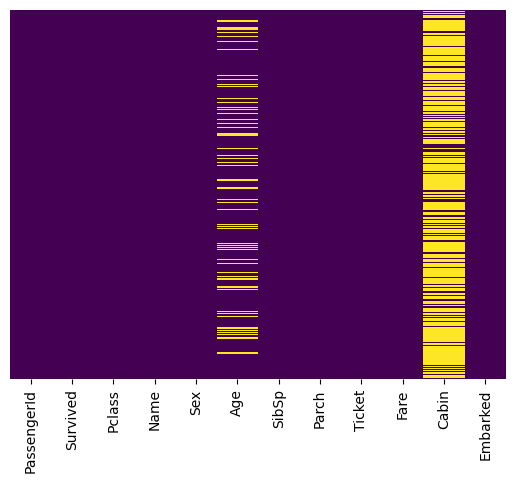

In [6]:
# Use seaborn to conduct heatmap to identify missing data
# data -> argument refers to the data to create heatmap
# yticklabels -> argument avoids plotting the column names
# cbar -> argument identifies if a colorbar is required or not
# cmap -> argument identifies the color of the heatmap
sns.heatmap(data = missing_values, yticklabels=False, cbar=False, cmap='viridis')

### Step 1: Viewing the ratios of the labels


<Axes: xlabel='Survived', ylabel='count'>

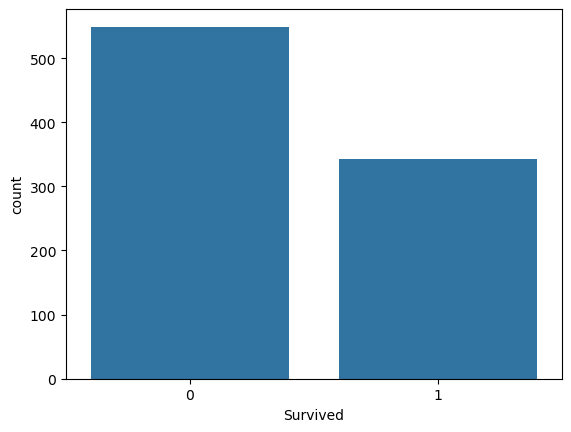

In [7]:
# Use the countplot() method to identify ratio of who survived vs. not
# (Tip) very helpful to get a visualization of the target label
# x -> argument refers to column of interest
# data -> argument refers to dataset
sns.countplot(x='Survived', data=train)

#### Survival Based on Category


<Axes: xlabel='Survived', ylabel='count'>

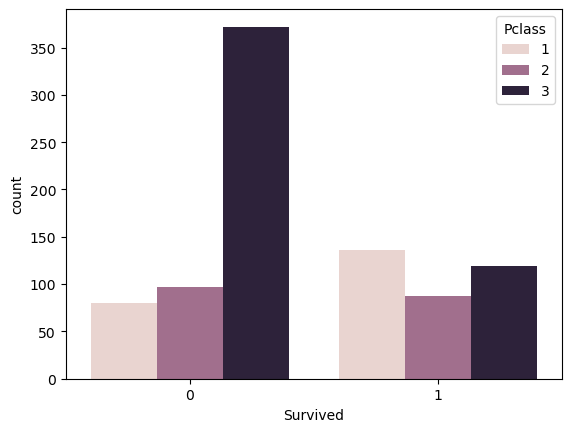

In [8]:
# Use the countplot() method to identify ratio of who survived vs. not with interest in Passenger class
# x -> argument refers to column of interest
# data -> argument refers to dataset
# hue -> allows another level to subdivide data
# palette -> argument refers to plot color
sns.countplot(x='Survived', data=train, hue='Pclass')

**What to do with all this missing data?**


We can impute or infill these values based on the data distribution

- When doing this it is important to look at the data distribution to make sure this makes sense


<Axes: xlabel='Pclass', ylabel='Age'>

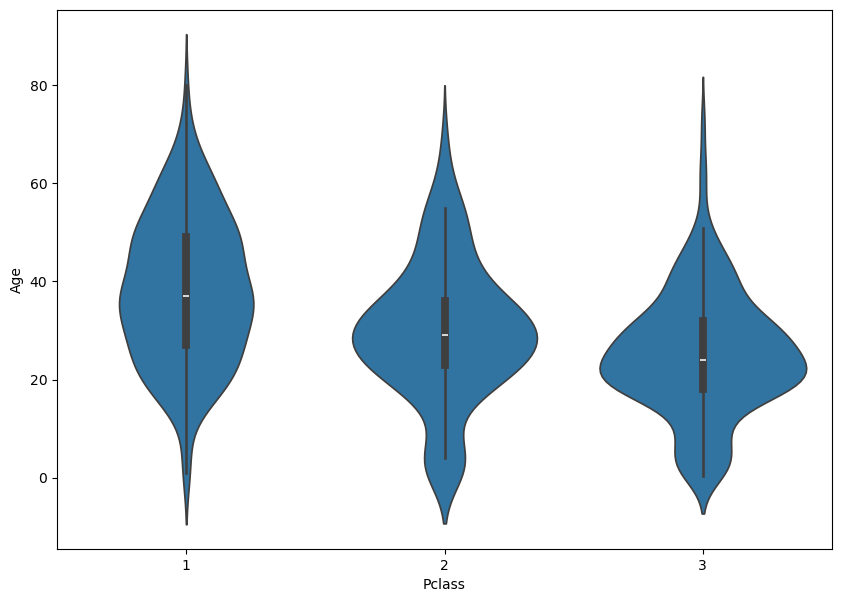

In [9]:
plt.figure(figsize=(10,7))
sns.violinplot(x='Pclass', y='Age', data = train)

### Step 2: Create a function to Impute Missing Values


In [10]:
train['Survived'].value_counts()


0    549
1    342
Name: Survived, dtype: int64

In [11]:
# Create function to impute the age value if it is null
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age
    
    
# Apply function to impute the age for missing values
# The age column is at position 0
# The pclass column is at position 1
# axis -> argument refers to columns instead of rows to apply the impute_age function
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

In [12]:
# Create function to replace the few empty Embark Values
def impute_embark(cols, value):
    embark = cols[0]
    
    if pd.isnull(embark):
        return value
    else: 
        return embark
    
train['Embarked'] = train[['Embarked']].apply(impute_embark, axis=1, args = (train['Embarked'].mode()[0]))

In [13]:
train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

### Step 3: Visualize Imputed Results


**It is always important when you modify data you check that it worked**


<Axes: >

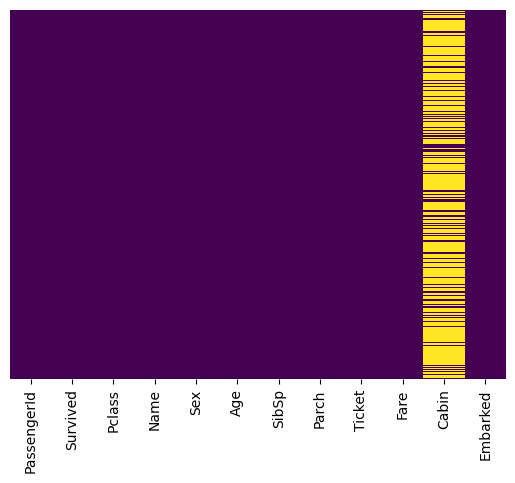

In [14]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

**There are barely any cabin entries we should ignore them**


In [15]:
train = train.drop(columns=['Cabin'])

In [16]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [17]:
# use .dropna() method to remove rows that contain missing values
train.dropna(inplace=True)

In [18]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Step 4: Encoding Categorical Variables

**What should we do with categorical variables?**


We need to convert categorical variables (not understood by computers) into dummy variables that can be understood.


- Produces what is known as a one-hot encoded vector


![](./figs/one_hot_encoded.png)


In [19]:
train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [20]:
train['Sex']

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [21]:
# Use the .get_dummies() method to convert categorical data into dummy values
# train['Sex'] refers to the column we want to convert
# drop_first -> argument avoids the multicollinearity problem, which can undermines
# the statistical significance of an independent variable.
sex = pd.get_dummies(train['Sex'], drop_first=True) # drop first means k-1 values
embark = pd.get_dummies(train['Embarked'], drop_first=True)

# Use  .concat() method to merge the series data into one dataframe
train = pd.concat([train, sex, embark], axis=1)

In [22]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,0,0


### Step 5: Data Filtering

Remove any insignificant features from the dataset


In [23]:
# Drop columns with categorical data

train.drop(['Sex','Embarked','Ticket','Name','PassengerId'], axis=1, inplace=True)

### Step 6: Split the data into features and labels


In [24]:
# Split data into 'X' features and 'y' target label sets

X = train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q',
       'S']]
y = train['Survived']

### Step 7: Test/Train Split


In [25]:
# Split data set into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

### Step 8: Create and Train the Model


In [26]:
# Create instance (i.e. object) of LogisticRegression
logmodel = LogisticRegression()

# Fit the model using the training data
# X_train -> parameter supplies the data features
# y_train -> parameter supplies the target labels
logmodel.fit(X_train, y_train)

c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# Create instance (i.e. object) of KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [28]:
# Use the .predict() method to make predictions on the test data for the KNN model

from sklearn.metrics import classification_report

pred_knn = knn.predict(X_test)
print(classification_report(y_test, pred_knn))

predictions = logmodel.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74       159
           1       0.62      0.60      0.61       109

    accuracy                           0.69       268
   macro avg       0.68      0.68      0.68       268
weighted avg       0.69      0.69      0.69       268

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       159
           1       0.80      0.67      0.73       109

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.78       268
weighted avg       0.80      0.80      0.79       268



### Step 9: Score the Model

#### F1-Score

It is calculated from the precision and recall of the test

- **Precision** is the number of true positive results divided by the number of all positive results, including those not identified correctly
  - known as positive predictive value

$$ Precision = \frac{True\,Positives}{True\,Positives + False\,Positives} $$

    - within everything that is predicted positive this is the percentage correct


- **Recall** is the number of true positive results divided by the number of all samples that should have been identified as positive.
  - known as sensitivity in diagnostic binary classification

$$ Recall = \frac{True\,Positives}{True\,Positives + False\,Negatives} $$

    - what is the fraction of actual positive results the model found


$$
F_1 = \frac{2}{\mathrm{recall}^{-1} + \mathrm{precision}^{-1}} = 2 \frac{\mathrm{precision} \cdot \mathrm{recall}}{\mathrm{precision} + \mathrm{recall}} = \frac{2\mathrm{tp}}{2\mathrm{tp} + \mathrm{fp} + \mathrm{fn}}
$$


### Step 10: Visualizing Results


In [29]:
# computes the confusion matrix
cm = confusion_matrix(y_test, predictions)

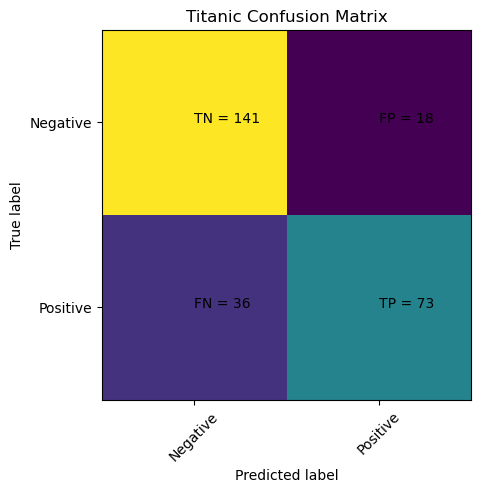

In [30]:
# Plots the confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.viridis)
classNames = ['Negative','Positive']
plt.title('Titanic Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [31]:
# logmodel f_1
f_1_log = (2*cm[1][1] / (2*cm[1][1] + cm[0][1] + cm[1][0]))
f_1_log

0.73

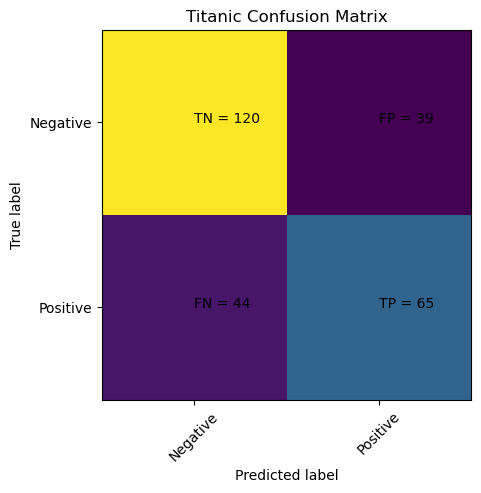

In [32]:
#Visualize the confusion matrix for the KNN model
cm = confusion_matrix(y_test, pred_knn)

plt.clf()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.viridis)
classNames = ['Negative','Positive']
plt.title('Titanic Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation=45)
plt.yticks(tick_marks, classNames)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
plt.show()

In [33]:
y_test
y_test.value_counts()

0    159
1    109
Name: Survived, dtype: int64

In [34]:
y_train.value_counts()

0    390
1    233
Name: Survived, dtype: int64

In [35]:
# knn f_1
f_1_knn = (2*cm[1][1] / (2*cm[1][1] + cm[0][1] + cm[1][0]))
f_1_knn

0.6103286384976526

### Step 11. Analysis

Compare the performance of the two classification models and provide an analysis of their results.

**Your Answer:** The Logmodel did a much better job of classification. It correctly predicted 214/268 survivors compared to knn which only predicted 185/268. This is reflected in the f_1 scores of .73 for the logmodel and .61 for the knn model. This appears to be due to the logmodel's ability to find true negatives. Also, the logmodel was better at predicting positives, and predicting negatives than the knn, so the logmodel was clearly better for this data. 

### Task: Predict Titanic Survival

Load the **new Titanic test dataset (titanic_unseen.csv)**, which is separate from the data used to train and evaluate the models.

- Apply the same preprocessing used during training.
- Use the trained **Logistic Regression** and **KNN** models to predict passenger survival.
- Compare the predictions from both models and identify any differences.

> **Goal:** Use the trained models to predict survival on completely unseen Titanic data.


In [36]:
train = pd.read_csv('titanic_unseen.csv')
train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [37]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

In [38]:
train['Embarked'] = train[['Embarked']].apply(impute_embark, axis=1, args = (train['Embarked'].mode()[0]))

In [39]:
train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S


In [40]:
train = train.drop(columns=['Cabin'])
train.dropna(inplace=True)

In [41]:
sex = pd.get_dummies(train['Sex'], drop_first=True) # drop first means k-1 values
embark = pd.get_dummies(train['Embarked'], drop_first=True)

# Use  .concat() method to merge the series data into one dataframe
train = pd.concat([train, sex, embark], axis=1)

In [42]:
train.drop(['Sex','Embarked','Ticket','Name','PassengerId'], axis=1, inplace=True)

In [43]:

X = train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q',
       'S']]
X

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,34.5,0,0,7.8292,1,1,0
1,3,47.0,1,0,7.0000,0,0,1
2,2,62.0,0,0,9.6875,1,1,0
3,3,27.0,0,0,8.6625,1,0,1
4,3,22.0,1,1,12.2875,0,0,1
...,...,...,...,...,...,...,...,...
413,3,24.0,0,0,8.0500,1,0,1
414,1,39.0,0,0,108.9000,0,0,0
415,3,38.5,0,0,7.2500,1,0,1
416,3,24.0,0,0,8.0500,1,0,1


In [44]:
pred_knn = knn.predict(X)

predictions = logmodel.predict(X)

print(pd.Series(pred_knn).value_counts(), pd.Series(predictions).value_counts())


0    269
1    148
dtype: int64 0    264
1    153
dtype: int64


The knn model tends to predict negatively more often than the logmodel. This may indicate that the knn model leans towards just predicting the mode of the data set stronger than the logmodel does.

## Multiclass classification

If you have several classes to predict, an option often used is to fit one-versus-all classifiers and then use a voting heuristic for the final decision.


In [45]:
from sklearn.datasets import load_iris

# loads the dataset
X, y = load_iris(return_X_y=True)

# Instantiates the model and computes the logistic regression
clf = LogisticRegression(random_state=0, solver='lbfgs',
                         multi_class='multinomial').fit(X, y)

# This predicts the classes
clf.predict(X[:2, :])

c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0])

In [46]:
# predicting the probability
clf.predict_proba(X[:2, :]) 

array([[9.81799203e-01, 1.82007824e-02, 1.44272072e-08],
       [9.71729178e-01, 2.82707921e-02, 3.01668533e-08]])

In [47]:
# Shows the score for the model
clf.score(X, y)

0.9733333333333334

## Adult Data Set

The **Adult data set**, also known as the "Census Income" data set, is a another popular classification data set. Whereas Iris is particularly simple and often used only for learning, testing, and examples, the Adult data set is often used in ML research papers.

This data set is part of the [UCI machine learning repository](https://archive.ics.uci.edu/), which contains 664 different data sets that you can browse. [OpenML](https://www.openml.org/) is a platform that hosts many data sets, *including* many from the UCI ML repository. Scikit-learn provides functions for loading data sets from OpenML, which can be used to load the Adult data set. Note that you could also find and download the data set directly and load it from your machine locally. These loading functions don't require you to send the data set with your code, but do cause your programs to download them (at least once) when your code is run.

### Data Set Overview

The Adult data set is extracted from the 1994 Census database of the United States. It is commonly used for predicting whether an individual's income exceeds $50,000 per year based on census data. This task is framed as a binary classification problem.

### Features

The data set contains 14 attributes, including:

1. **Age**: The age of the individual.
2. **Workclass**: The type of employer the individual has (e.g., private, federal-gov).
3. **fnlwgt**: Final weight. The number of people the census believes the entry represents. E.g., a value of 50 means that the person's data represents 50 people in the real population with similar attributes. Individual people can be represented by multiple rows, so `fnlwgt` does not sum to the US population. This "binning" of people helps to preserve privacy.
4. **Education**: The highest level of education achieved by the individual.
5. **Education-Num**: The highest level of education in numerical form.
6. **Marital Status**: Marital status of the individual.
7. **Occupation**: The individual's occupation.
8. **Relationship**: The individual's role in the family.
9. **Race**: The race of the individual.
10. **Sex**: The gender of the individual.
11. **Capital Gain**: Income from investment sources, apart from wages/salary.
12. **Capital Loss**: Losses from investment sources, apart from wages/salary.
13. **Hours per Week**: Number of hours worked per week.
14. **Native Country**: Country of origin for the individual.

### Target Variable

- **Income**: Whether the individual earns more than $50,000 per year.


In [48]:
from sklearn.datasets import fetch_openml                                       # OpenML contains many useful data sets, including Adult.

adult = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')     # Fetch the Adult dataset. as_frame=True indicates that we're using pandas and makes adult.data a DataFrame (among other changes)
df = adult.data                                                                 # Pull off the DataFrame, as we will manipulate it to append the labels
df['income'] = adult.target                                                     # Add the target column (what we aim to predict)
display(df)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


**Question**: Is each column numerical, categorical, text, or an image? Continuous, discrete, nominal, or ordinal?  
Age: numerical continuous  
Workclass: Categorical  
fnlwgt: numerical, continuous  
Education: categorical  
Education-Num: numerical discrete  
Marital Status: categorical  
Occupation: categorical  
Relationship: categorical  
Race: categorical  
Sex: categorical  
Capital Gain: numerical, continuous  
Capital Loss: numerical, continuous  
Hours per Week: numerical, continuous  
Native Country: numerical, continuous  



A DataFrame object stores information about the type of each column in `DataFrame.dtype`:

In [49]:
# We can get the types of columns using .dtype. This is a type object, not a string.
print('Second column .dtype is:');
print('\tType: ', type(df['workclass'].dtype))
print('\tValue: ', df['workclass'].dtype)

# We can get the string representation of the type with dtype.name. This is useful when we want to compare the type to a string.
print('Second column .dtype.name is:');
print('\tType: ', type(df['workclass'].dtype.name))
print('\tValue: ', df['workclass'].dtype.name)

Second column .dtype is:
	Type:  <class 'pandas.core.dtypes.dtypes.CategoricalDtype'>
	Value:  category
Second column .dtype.name is:
	Type:  <class 'str'>
	Value:  category


For columns that are categorical, we can query the set of possible categories:

In [50]:
df['workclass'].cat.categories # Returns a pandas Index of unique categories in the 'workclass' column.

Index(['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc',
       'Self-emp-not-inc', 'State-gov', 'Without-pay'],
      dtype='object')

Above, the '.cat' accessor is used for accessing categorical data specific methods and attributes. 

The table below describes common values of dtype in pandas:

| Pandas dtype    | Description / Usage                                           |
|-----------------|---------------------------------------------------------------|
| `object`        | Typically strings or mixed types.                             |
| `int64`         | Integer numbers.                                              |
| `float64`       | Floating point numbers.                                       |
| `bool`          | Boolean values (True or False).                               |
| `datetime64`    | Date and time values.                                         |
| `category`      | Finite list of text values. Useful for categorical variables. |


Let's use these tools to get the type and values of each possible feature:

In [51]:
# Notice that df.columns is an attribute of a DataFrame of type pandas Index, which stores the column names.
print("df.columns:");
display(df.columns)

print("\nHere are the possible values for all categorical columns:")
# Iterate through each column and print the feature name and unique values or type. 
for column in df.columns:                                               # Note that pandas.Index is "iterable" in this way.
    # Check if the column is of object type (categorical)
    if df[column].dtype.name == 'category':
        # Print the feature name and its unique values
        print(f"\033[1m{column}:\033[0m {df[column].cat.categories}")   # \033[1m sets to bold, and \033[0m back to normal text.
    else:
        # Print the feature name and its type
        print(f"\033[1m{column} (numerical):\033[0m {df[column].dtype}")

df.columns:


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


Here are the possible values for all categorical columns:
age (numerical): int64
workclass: Index(['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc',
       'Self-emp-not-inc', 'State-gov', 'Without-pay'],
      dtype='object')
fnlwgt (numerical): int64
education: Index(['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th',
       'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad',
       'Masters', 'Preschool', 'Prof-school', 'Some-college'],
      dtype='object')
education-num (numerical): int64
marital-status: Index(['Divorced', 'Married-AF-spouse', 'Married-civ-spouse',
       'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'],
      dtype='object')
occupation: Index(['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial',
       'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct',
       'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv',
       'Sales', 'Tech-support', 'Transport-mov

### Task: Build Classification Models

Using the **Adult Data Set**, build and evaluate classification models to predict whether an individual's annual income is **greater than $50,000**.

1. **Prepare the data** by identifying the features and target variable, handling missing values, and converting categorical variables into a suitable numerical format.

2. **Split the data** into training and testing sets.

3. **Standardize the appropriate numerical features**, particularly for K-Nearest Neighbors.

4. Build a **Logistic Regression** model to predict the `Income` target.

5. Build a **K-Nearest Neighbors (KNN)** model and select an appropriate value of \(k\).

6. Use both models to **make predictions** on the test data.

7. **Evaluate and compare** the models using appropriate classification metrics, such as accuracy, precision, recall, F1-score, and a confusion matrix.

8. **Analyze the results** and discuss which model performs better and why.

> **Goal:** Use the individual's census characteristics to predict whether their income exceeds **$50,000 per year**, and compare the performance of Logistic Regression and KNN on this classification task.


In [52]:
df.shape

(48842, 15)

In [53]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [54]:
missing_values = df.isnull()
missing_values

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48838,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48839,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

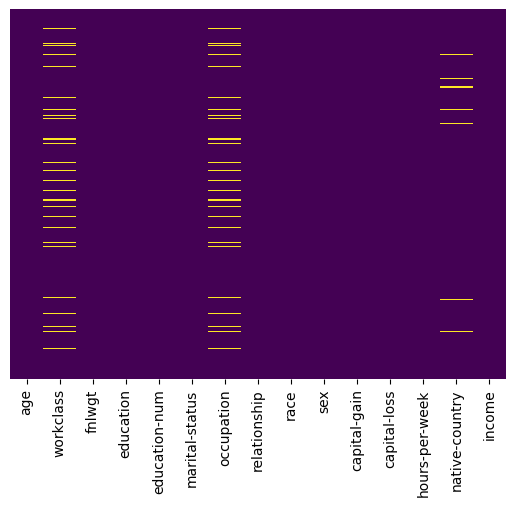

In [55]:
sns.heatmap(data = missing_values, yticklabels=False, cbar=False, cmap='viridis')

In [56]:
rows_missing_values = missing_values[missing_values.any(axis=1)]
rows_missing_values.shape

(3620, 15)

I actually want to train on all three columns that have missing data, so I dont want to drop the column as a whole or distort the data with it. Only ~1/16 of the rows having missing data, so I will just drop the columns with missing data. 

In [57]:
df.dropna(inplace=True)

In [58]:
# Tried this the first time with occupation included, but got a 'could not converge' error.
df = df.drop(columns= ['education', 'fnlwgt', 'relationship', 'occupation'])

In [59]:
def impute_country(place):
    
    if str(place) =='United-States':
        return 1
    else: 
        return 0

def impute_workclass(work):
    if 'gov' in work:
        return 1
    else:
        return 0 
def impute_married(marry):
    if str(marry) == 'Married-civ-spouse':
        return 1
    else:
        return 0
   
df['workclass'] = df['workclass'].apply(impute_workclass)
df['native-country'] = df['native-country'].apply(impute_country)
df['marital-status'] = df['marital-status'].apply(impute_married)

In [60]:
df['marital-status'].unique

<bound method Series.unique of 0        0
1        1
2        1
3        1
5        0
        ..
48837    1
48838    1
48839    0
48840    0
48841    1
Name: marital-status, Length: 45222, dtype: int64>

In [61]:
df.head()

,age,workclass,education-num,marital-status,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,0,7,0,Black,Male,0,0,40,1,<=50K
1,38,0,9,1,White,Male,0,0,50,1,<=50K
2,28,1,12,1,White,Male,0,0,40,1,>50K
3,44,0,10,1,Black,Male,7688,0,40,1,>50K
5,34,0,6,0,White,Male,0,0,30,1,<=50K


In [66]:
race = pd.get_dummies(df['race'], drop_first=True) # drop first means k-1 values
sex = pd.get_dummies(df['sex'], drop_first=True)

# Use  .concat() method to merge the series data into one dataframe
df = pd.concat([df, sex, race], axis=1)
df.drop(['sex','race'], axis=1, inplace=True)
df.head()

,age,workclass,education-num,marital-status,capital-gain,capital-loss,hours-per-week,native-country,income,Male,Asian-Pac-Islander,Black,Other,White
0,25,0,7,0,0,0,40,1,<=50K,1,0,1,0,0
1,38,0,9,1,0,0,50,1,<=50K,1,0,0,0,1
2,28,1,12,1,0,0,40,1,>50K,1,0,0,0,1
3,44,0,10,1,7688,0,40,1,>50K,1,0,1,0,0
5,34,0,6,0,0,0,30,1,<=50K,1,0,0,0,1


In [67]:
X = df.drop(columns = ['income'])
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

In [68]:
type(y_train)

pandas.core.series.Series

In [72]:
knn = KNeighborsClassifier(n_neighbors = 9)
logmodel = LogisticRegression()

knn.fit(X_train,y_train)
logmodel.fit(X_train,y_train)

knn_pred = knn.predict(X_test)
log_pred = logmodel.predict(X_test)

knn_cm = confusion_matrix(y_test, knn_pred)
log_cm = confusion_matrix(y_test, log_pred)

print(classification_report(y_test, knn_pred))

print(classification_report(y_test, log_pred))

c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90     10211
        >50K       0.71      0.60      0.65      3356

    accuracy                           0.84     13567
   macro avg       0.79      0.76      0.77     13567
weighted avg       0.83      0.84      0.84     13567

              precision    recall  f1-score   support

       <=50K       0.84      0.93      0.88     10211
        >50K       0.68      0.48      0.56      3356

    accuracy                           0.81     13567
   macro avg       0.76      0.70      0.72     13567
weighted avg       0.80      0.81      0.80     13567



Both models performed fairly well with high f1-scores. The knn model out performed the logmodel (different results from above) on this set of data. I think this is primarily because of the recall on the >50k targets where knn had a 60% recall compared to logmodel's 48%. I got a warning that the logmodel failed to converge, so this impacts this result, however it is relevant to mention that the knn was effective on the data. Maybe this points to knn requiring less training data than a logistic regression algorithm.